**Project Title**

Hospital Resource Utilization

Analysis Using AI & Machine Learning

Domain: Healthcare Analytics


---


Leader in Consulting

https://gncipl.com/

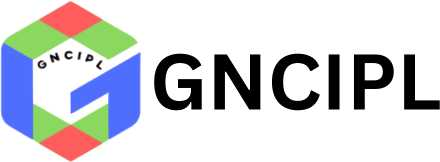

**GitHub Repository**

https://github.com/simranbhadouria/Hospital-Resource-Utilization-project-8

**Dataset**

https://www.kaggle.com/datasets/dimpimittal/smart-hospital-resource-analysis

**Objective**

The primary objective of this project is to analyze hospital resource utilization using healthcare operational data and machine learning techniques. The project focuses on understanding bed occupancy patterns, staff allocation efficiency, patient admission trends, and treatment-related resource consumption to support better hospital management and decision-making.

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,r2_score

Load Dataset

In [ ]:
df = pd.read_csv("/content/hospital_insights_summary.csv")

Dataset Overview

In [ ]:
df.head()

,week,service,patients_admitted,avg_stay,avg_satisfaction,max_occupancy,staff_count,recommended_staff
0,1,ICU,7,5.428571,84.857143,14,34,2.0
1,1,emergency,4,9.250000,86.000000,13,39,1.0
2,1,general_medicine,5,7.400000,77.400000,12,28,1.0
3,1,surgery,6,10.000000,84.666667,11,25,2.0
4,2,ICU,4,8.000000,69.250000,13,34,1.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   week               208 non-null    int64  
 1   service            208 non-null    object 
 2   patients_admitted  208 non-null    int64  
 3   avg_stay           208 non-null    float64
 4   avg_satisfaction   208 non-null    float64
 5   max_occupancy      208 non-null    int64  
 6   staff_count        208 non-null    int64  
 7   recommended_staff  208 non-null    float64
dtypes: float64(3), int64(4), object(1)
memory usage: 13.1+ KB


In [ ]:
df.describe()

,week,patients_admitted,avg_stay,avg_satisfaction,max_occupancy,staff_count,recommended_staff
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,26.500000,4.807692,7.494813,79.429424,11.427885,31.500000,1.326923
std,15.044539,2.113115,2.207160,5.987425,2.656610,5.421375,0.470221
min,1.000000,1.000000,2.000000,60.000000,3.000000,25.000000,1.000000
25%,13.750000,3.000000,6.000000,75.650000,10.000000,27.250000,1.000000
50%,26.500000,5.000000,7.500000,79.514286,12.000000,31.000000,1.000000
75%,39.250000,6.000000,8.750000,83.500000,13.000000,35.250000,2.000000
max,52.000000,10.000000,14.000000,96.500000,14.000000,39.000000,2.000000


In [ ]:
df.shape

(208, 8)

Missing Value Analysis

In [ ]:
df.isnull().sum()

,0
week,0
service,0
patients_admitted,0
avg_stay,0
avg_satisfaction,0
max_occupancy,0
staff_count,0
recommended_staff,0


Handle Missing Values

In [ ]:
#Numeric Columns
numeric_cols = df.select_dtypes(include=np.number)

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_666/89839678.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
#Categorical Columns
cat_cols = df.select_dtypes(include='object')

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_666/1945470911.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


Data Cleaning

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

Feature Engineering

In [ ]:
#Staff Utilization Ratio
df["staff_utilization"] = (df["patients_admitted"] /df["staff_count"])

In [ ]:
#Occupancy Percentage
df["occupancy_rate"] = (df["max_occupancy"] /df["max_occupancy"].max())*100

Exploratory Data Analysis (EDA)

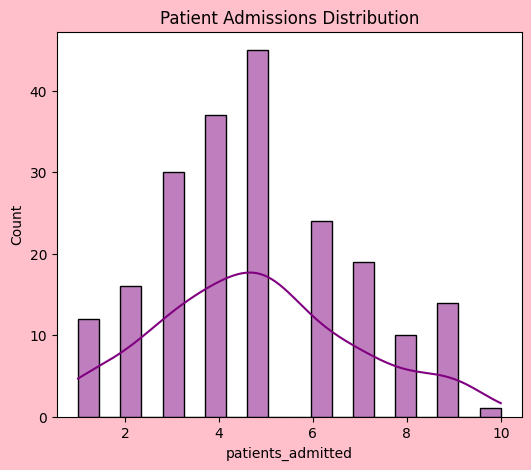

In [ ]:
#Patient Admissions Distribution
plt.figure(figsize=(6,5),facecolor ='pink')
sns.histplot(df["patients_admitted"],bins=20,kde=True,color = 'purple', edgecolor = 'black')
plt.title("Patient Admissions Distribution")

plt.show()

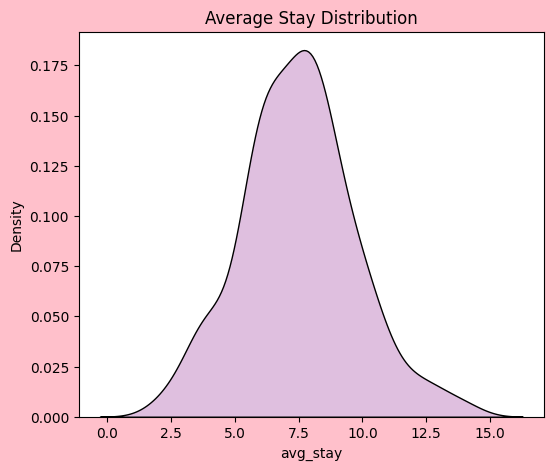

In [ ]:
# KDE Plot
plt.figure(figsize=(6,5),facecolor ='pink')
sns.kdeplot(df["avg_stay"],fill=True,color = 'purple', edgecolor = 'black')
plt.title("Average Stay Distribution")

plt.show()

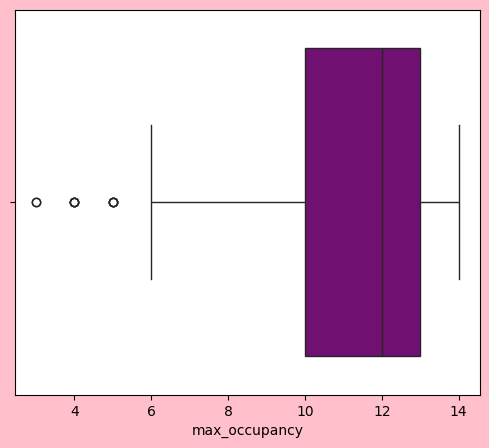

In [ ]:
#3 Boxplot
plt.figure(figsize=(6,5),facecolor ='pink')
sns.boxplot(x=df["max_occupancy"],color = 'purple')

plt.show()

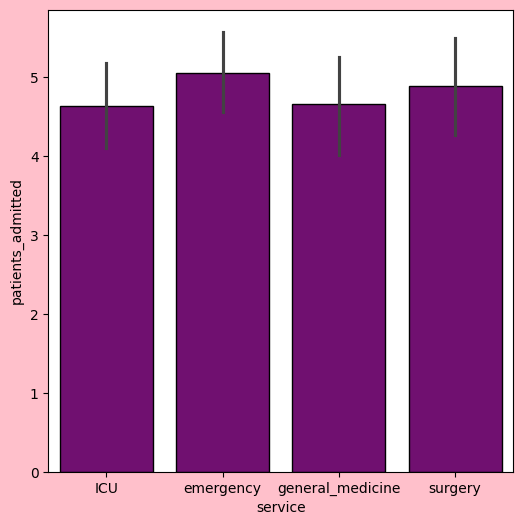

In [ ]:
#4 Service Wise Admissions
plt.figure(figsize=(6,6),facecolor ='pink')
sns.barplot(x="service",y="patients_admitted",data=df,color = 'purple', edgecolor = 'black')

plt.show()

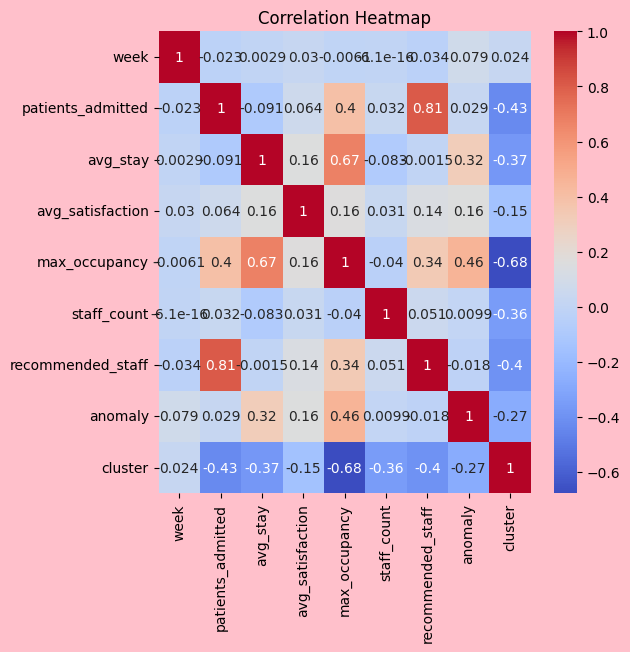

In [ ]:
#5 Correlation Heatmap
plt.figure(figsize=(6,6),facecolor ='pink')
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Time Series Analysis

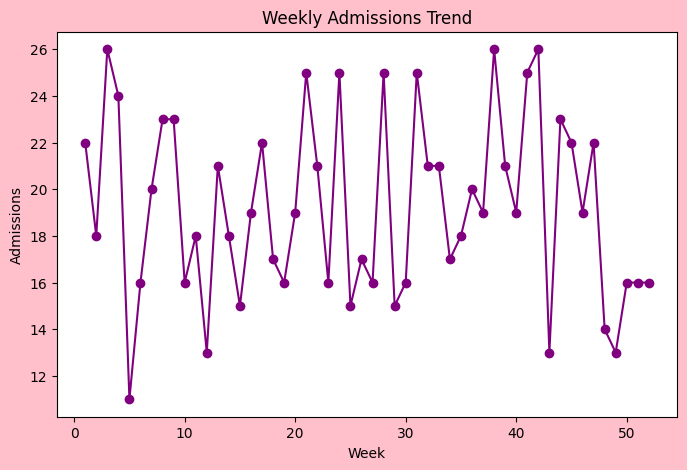

In [ ]:
#Monthly Admissions Trend
weekly = df.groupby("week")["patients_admitted"].sum()
plt.figure(figsize=(8,5),facecolor ='pink')
weekly.plot(marker="o",color = 'purple')
plt.xlabel("Week")
plt.ylabel("Admissions")
plt.title("Weekly Admissions Trend")

plt.show()

Demographic Stratification Equivalent

In [ ]:
service_summary = df.groupby("service")[["patients_admitted","avg_stay","avg_satisfaction"]].mean()
print(service_summary)

                  patients_admitted  avg_stay  avg_satisfaction
service                                                        
ICU                        4.634615  7.874557         79.665598
emergency                  5.057692  7.061516         79.770398
general_medicine           4.653846  7.064003         78.474626
surgery                    4.884615  7.979174         79.807074


Outlier Detection

In [ ]:
# Using IQR
Q1 = df["patients_admitted"].quantile(0.25)
Q3 = df["patients_admitted"].quantile(0.75)
IQR = Q3-Q1
outliers = df[(df["patients_admitted"]<Q1-1.5*IQR)|(df["patients_admitted"]>Q3+1.5*IQR)]
outliers.head()

,week,service,patients_admitted,avg_stay,avg_satisfaction,max_occupancy,staff_count,recommended_staff,staff_utilization,occupancy_rate


Anomaly Detection

In [ ]:
features = df[["patients_admitted","max_occupancy","staff_count"]]
model = IsolationForest(contamination=0.05,random_state=42)
df["anomaly"] = model.fit_predict(features)

View Anomalies

In [ ]:
df[df["anomaly"]==-1]

,week,service,patients_admitted,avg_stay,avg_satisfaction,max_occupancy,staff_count,recommended_staff,staff_utilization,occupancy_rate,anomaly
6,2,general_medicine,2,2.500000,69.500000,3,28,1.0,0.071429,21.428571,-1
11,3,surgery,10,7.700000,84.000000,14,25,2.0,0.400000,100.000000,-1
13,4,emergency,9,6.555556,77.222222,11,39,2.0,0.230769,78.571429,-1
29,8,emergency,2,4.500000,72.500000,5,39,1.0,0.051282,35.714286,-1
58,15,general_medicine,3,2.000000,78.333333,3,28,1.0,0.107143,21.428571,-1
88,23,ICU,1,5.000000,72.000000,5,34,1.0,0.029412,35.714286,-1
101,26,emergency,4,3.250000,79.000000,4,39,1.0,0.102564,28.571429,-1
111,28,surgery,8,5.500000,77.875000,9,25,2.0,0.320000,64.285714,-1
119,30,surgery,1,4.000000,77.000000,4,25,1.0,0.040000,28.571429,-1
176,45,ICU,9,5.111111,81.555556,7,34,2.0,0.264706,50.000000,-1


Principal Component Analysis (PCA)

In [ ]:
features = df[["patients_admitted","avg_stay","avg_satisfaction","max_occupancy","staff_count"]]
scaler = StandardScaler()
scaled = scaler.fit_transform(features)

Principal Component Analysis (PCA) Apply

In [ ]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)
pca_df = pd.DataFrame(pca_result,columns=["PC1","PC2"])

Visualization

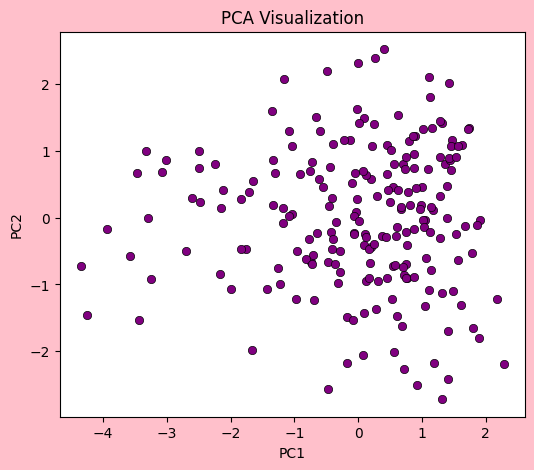

In [ ]:
plt.figure(figsize=(6,5),facecolor ='pink')
sns.scatterplot(x="PC1",y="PC2",data=pca_df, color = 'purple', edgecolor = 'black')

plt.title("PCA Visualization")
plt.show()

Clustering

In [ ]:
kmeans = KMeans(n_clusters=3,random_state=42)
clusters = kmeans.fit_predict( scaled)
df["cluster"] = clusters

Cluster Visualization

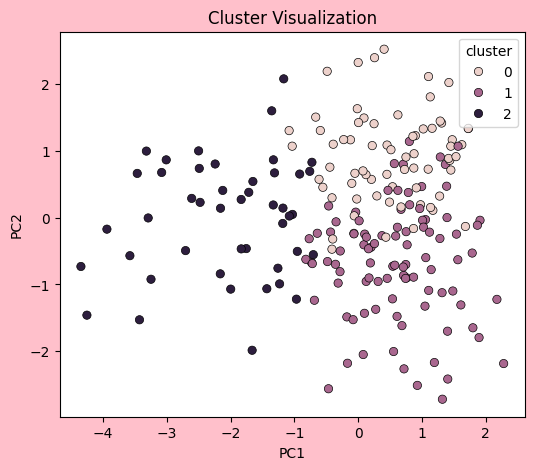

In [ ]:
plt.figure(figsize=(6,5),facecolor= "pink")
sns.scatterplot(x=pca_df["PC1"],y=pca_df["PC2"],hue=df["cluster"], color = 'purple', edgecolor = 'black')
plt.title("Cluster Visualization")

plt.show()

Machine Learning

In [ ]:
X = df[["patients_admitted","avg_stay","staff_count","avg_satisfaction"]]
y = df["max_occupancy"]

Split Data

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

Train Model

In [ ]:
rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

Prediction

In [ ]:
pred = rf.predict(X_test)

Evaluation

In [ ]:
print("MAE:", mean_absolute_error(y_test,pred))
print("R2 Score:", r2_score(y_test,pred))

MAE: 1.1811904761904761
R2 Score: 0.6223899787158567


Feature Importance

In [ ]:
importance = pd.DataFrame({"Feature":X.columns,"Importance":rf.feature_importances_})
importance.sort_values(by="Importance",ascending=False)

,Feature,Importance
1,avg_stay,0.728787
0,patients_admitted,0.136638
3,avg_satisfaction,0.096358
2,staff_count,0.038218


**PROJECT CONCLUSION**

1. Hospital resource utilization was analyzed using patient admissions,
   occupancy levels, staffing information, and satisfaction scores.

2. Exploratory Data Analysis revealed important trends in hospital
   operations and resource demand.

3. Correlation analysis showed strong relationships between admissions,
   occupancy, and staffing requirements.

4. Outlier detection identified abnormal operational periods that may
   require management attention.

5. Isolation Forest successfully detected unusual hospital workload
   patterns and resource utilization anomalies.

6. PCA reduced data complexity while preserving important information.

7. K-Means Clustering segmented hospital utilization into low, medium,
   and high resource usage groups.

8. Random Forest Regression predicted occupancy levels using hospital
   operational features.

9. The insights generated can help hospitals improve staffing decisions,
   optimize bed allocation, and enhance patient care.

10. This project demonstrates the practical application of Data Analytics,
    Machine Learning, and Healthcare Intelligence in solving real-world
    hospital management challenges.
